In [ ]:
!pip install mpi4py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mpi4py: filename=mpi4py-3.1.5-cp310-cp310-linux_x86_64.whl size=2746522 sha256=f24990b2c41f8b2201e027b85f17e37cc2229f9fd0ad6f449815ca8dc9a7072b
  Stored in directory: /root/.cache/pip/wheels/18/2b/7f/c852523089e9182b45fca50ff56f49a51eeb6284fd25a66713
Successfully built mpi4py


In [1]:
%%writefile gather2.py
import matplotlib.pyplot as plt
from mpi4py import MPI
import numpy as np
import random
import time
import warnings
import os
warnings.filterwarnings('ignore')

def bif(r, n, m):
    X = np.zeros(n)
    X[0] = 0.1
    for i in range(1,n):
        X[i] = X[i-1] * r * (1 - X[i-1])
    return X[n-m:]

t_start = time.time()


comm = MPI.COMM_WORLD

rank = comm.Get_rank()
size = comm.Get_size()

R_size = 15000
rank_size = R_size // size
m = 200
n = 200

root = 0

R = np.linspace(1, 10, R_size)

if rank == size - 1:
    rank_size += R_size % size
    start, end = rank * rank_size, R_size

else:
    start, end = rank * rank_size, (rank + 1) * rank_size

Array = np.empty((0, m))
R_ = np.empty((0, m))

for r in R[start:end]:
    Array = np.append(Array, np.array([bif(r,m + n,m)]), axis=0)
    R_ = np.append(R_, [np.dot(np.ones(m), r)], axis=0)

Array = comm.gather(Array, root=0)
R_ = comm.gather(R_, root=0)

if rank == 0:
    t_end = time.time()
    dt = t_end - t_start
    with open('results3.csv', 'a+') as f:
       f.write(f'{dt} ')

Writing gather2.py


In [ ]:
for i in range(1,10):
  !mpirun -n $i --allow-run-as-root --oversubscribe python3 gather2.py

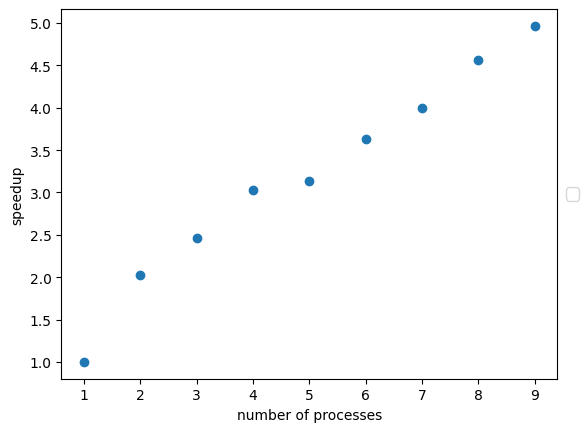

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = []
with open('results3.csv', 'r') as results:
    data = results.readlines()[0].split(' ')
    data = np.array([float(i) for i in data[:-1]] )

plt.plot(np.arange(1, 10, 1),data[0] / data , '-o')
plt.xlabel('number of processes')
plt.ylabel('speedup')